In [75]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [76]:
# ===== Cell 1: Imports =====
import os
import json
import numpy as np
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import resnet34, ResNet34_Weights

In [77]:
# ===== Cell 2: Paths + Category Mapping =====

# Your selected categories (original → new labels)
category_map = {
    1:1,   # short sleeve top
    2:2,   # long sleeve top
    7:3,   # shorts
    8:4,   # trousers
    9:5    # skirt
}

NUM_CLASSES = 5

In [78]:
# ===== Cell 3: JSON → Mask =====

def create_mask(annotation_path, image_shape, category_map):
    mask = np.zeros((image_shape[0], image_shape[1]), dtype=np.uint8)

    with open(annotation_path, 'r') as f:
        data = json.load(f)

    for key in data:
        if not key.startswith("item"):
            continue

        obj = data[key]
        original_cat = obj["category_id"]

        # skip unwanted categories
        if original_cat not in category_map:
            continue

        mapped_cat = category_map[original_cat]

        for seg in obj["segmentation"]:
            poly = np.array(seg).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [poly], mapped_cat)

    return mask

In [79]:
class FashionDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, category_map):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.category_map = category_map
        self.files = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img_path = os.path.join(self.image_dir, name)
        ann_path = os.path.join(self.annotation_dir, name.replace(".jpg",".json"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = create_mask(ann_path, image.shape, self.category_map)

        image = cv2.resize(image, (256,256))
        mask  = cv2.resize(mask, (256,256), interpolation=cv2.INTER_NEAREST)

        image = image / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)
        mask  = torch.tensor(mask, dtype=torch.long)

        return image, mask



In [80]:
# ===== Cell 11: Separate datasets =====

TRAIN_IMAGE_DIR = "/kaggle/input/datasets/gouravanirudh/fashion/processed/train/images"
TRAIN_ANN_DIR   = "/kaggle/input/datasets/gouravanirudh/fashion/processed/train/annos"

VAL_IMAGE_DIR = "/kaggle/input/datasets/gouravanirudh/fashion/processed/validation/images"
VAL_ANN_DIR   = "/kaggle/input/datasets/gouravanirudh/fashion/processed/validation/annos"

train_dataset = FashionDataset(TRAIN_IMAGE_DIR, TRAIN_ANN_DIR, category_map)
val_dataset   = FashionDataset(VAL_IMAGE_DIR, VAL_ANN_DIR, category_map)

print(len(train_dataset), len(val_dataset))

144174 23741


In [81]:
# ===== Cell 12 =====

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [82]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = resnet34(weights=ResNet34_Weights.DEFAULT)

        self.initial = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

    def forward(self, x):
        x0 = self.initial(x)
        x1 = self.maxpool(x0)

        x2 = self.layer1(x1)
        x3 = self.layer2(x2)
        x4 = self.layer3(x3)
        x5 = self.layer4(x4)

        return x0, x2, x3, x4, x5

In [83]:
class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_c, out_c, 2, 2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_c + skip_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [84]:
class UNetResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.encoder = Encoder()

        self.dec4 = DecoderBlock(512,256,256)
        self.dec3 = DecoderBlock(256,128,128)
        self.dec2 = DecoderBlock(128,64,64)
        self.dec1 = DecoderBlock(64,64,64)

        self.final_up = nn.ConvTranspose2d(64,64,2,2)
        self.final = nn.Conv2d(64, num_classes+1, 1)

    def forward(self, x):
        x0,x2,x3,x4,x5 = self.encoder(x)

        x = self.dec4(x5,x4)
        x = self.dec3(x,x3)
        x = self.dec2(x,x2)
        x = self.dec1(x,x0)

        x = self.final_up(x)
        return self.final(x)

model = UNetResNet(NUM_CLASSES)
print(model(torch.randn(1,3,256,256)).shape)

torch.Size([1, 6, 256, 256])


In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# freeze encoder
for p in model.encoder.parameters():
    p.requires_grad = False

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

In [89]:
# ===== Metrics =====
def dice_score(pred, target, num_classes):
    pred = torch.argmax(pred, dim=1)

    dice_total = 0.0
    valid_classes = 0

    for cls in range(1, num_classes + 1):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()
        denom = pred_cls.sum() + target_cls.sum()

        if denom == 0:
            continue

        dice_cls = (2.0 * intersection) / (denom + 1e-6)

        # 🔥 clamp just for safety
        dice_cls = torch.clamp(dice_cls, 0, 1)

        dice_total += dice_cls
        valid_classes += 1

    return dice_total / valid_classes if valid_classes > 0 else torch.tensor(0.0)


def iou_score(pred, target, num_classes):
    pred = torch.argmax(pred, dim=1)

    iou_total = 0.0
    valid_classes = 0

    for cls in range(1, num_classes + 1):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum() - intersection

        if union == 0:
            continue

        iou_cls = intersection / (union + 1e-6)

        iou_cls = torch.clamp(iou_cls, 0, 1)

        iou_total += iou_cls
        valid_classes += 1

    return iou_total / valid_classes if valid_classes > 0 else torch.tensor(0.0)

In [87]:
print(device)

cuda


In [88]:
from tqdm import tqdm

EPOCHS = 10
FREEZE_EPOCHS = 7

# best_dice = 0.0
best_iou = 0.0

# Freeze encoder initially
for p in model.encoder.parameters():
    p.requires_grad = False

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # 🔥 Unfreeze after 7 epochs
    if epoch == FREEZE_EPOCHS:
        print("🔥 Unfreezing encoder...")
        for p in model.encoder.parameters():
            p.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # ===== TRAIN =====
    model.train()

    train_loss = 0
    train_dice = 0
    train_iou = 0

    loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}")

    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        dice = dice_score(outputs, masks, NUM_CLASSES)
        iou = iou_score(outputs, masks, NUM_CLASSES)

        train_dice += dice.item()
        train_iou += iou.item()

        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    
    val_loss = 0
    val_dice = 0
    val_iou = 0
    
    val_loop = tqdm(val_loader, desc=f"Val Epoch {epoch+1}")
    
    with torch.no_grad():
        for images, masks in val_loop:
            images = images.to(device)
            masks = masks.to(device)
    
            outputs = model(images)
            loss = criterion(outputs, masks)
    
            val_loss += loss.item()
    
            dice = dice_score(outputs, masks, NUM_CLASSES)
            iou = iou_score(outputs, masks, NUM_CLASSES)
    
            val_dice += dice.item()
            val_iou += iou.item()
    
            # 🔥 show live validation loss
            val_loop.set_postfix(loss=loss.item())

            val_dice += dice.item()
            val_iou += iou.item()

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)

    # ===== PRINT =====
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train IoU: {train_iou:.4f}")
    print(f"Train Dice: {train_dice:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val IoU: {val_iou:.4f}")
    print(f"Val Dice: {val_dice:.4f}")

    # ===== SAVE BEST MODEL =====
    if (val_iou > best_iou):
        best_iou = val_iou
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved at epoch {epoch+1} (IoU: {val_iou:.4f})")


Epoch 1/10


Val Epoch 1: 100%|██████████| 2968/2968 [05:09<00:00,  9.59it/s, loss=0.114] 



Epoch 1/10
Train Loss: 0.3787
Train IoU: 0.3388
Train Dice: 0.4450
Val Loss: 0.3267
Val IoU: 0.6095
Val Dice: 0.7532
✅ Best model saved at epoch 1 (IoU: 0.6095)

Epoch 2/10


Val Epoch 2: 100%|██████████| 2968/2968 [02:15<00:00, 21.95it/s, loss=0.101] 



Epoch 2/10
Train Loss: 0.3044
Train IoU: 0.4464
Train Dice: 0.5622
Val Loss: 0.3041
Val IoU: 0.6830
Val Dice: 0.8288
✅ Best model saved at epoch 2 (IoU: 0.6830)

Epoch 3/10


...


Epoch 8/10
Train Loss: 0.2237
Train IoU: 0.5594
Train Dice: 0.6637
Val Loss: 0.2270
Val IoU: 0.9011
Val Dice: 1.0419
✅ Best model saved at epoch 8 (IoU: 0.9011)

Epoch 9/10


Val Epoch 9: 100%|██████████| 2968/2968 [02:15<00:00, 21.94it/s, loss=0.0923]



Epoch 9/10
Train Loss: 0.1822
Train IoU: 0.6198
Train Dice: 0.7155
Val Loss: 0.1982
Val IoU: 0.9467
Val Dice: 1.0852
✅ Best model saved at epoch 9 (IoU: 0.9467)

Epoch 10/10


Val Epoch 10: 100%|██████████| 2968/2968 [02:14<00:00, 22.10it/s, loss=0.0651]



Epoch 10/10
Train Loss: 0.1588
Train IoU: 0.6558
Train Dice: 0.7461
Val Loss: 0.2029
Val IoU: 0.9741
Val Dice: 1.1151
✅ Best model saved at epoch 10 (IoU: 0.9741)


In [90]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

UNetResNet(
  (encoder): Encoder(
    (initial): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, mo

In [91]:
val_dice = 0
val_iou = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        val_dice += dice_score(outputs, masks, NUM_CLASSES).item()
        val_iou += iou_score(outputs, masks, NUM_CLASSES).item()

val_dice /= len(val_loader)
val_iou /= len(val_loader)

print("Fixed Val Dice:", val_dice)
print("Fixed Val IoU:", val_iou)

Fixed Val Dice: 0.557544008054271
Fixed Val IoU: 0.4870573091625068


In [101]:
pred = torch.argmax(outputs, dim=1)  # [B, H, W]

In [102]:
import cv2

def get_bboxes(mask):
    """
    mask: [H, W] numpy array
    returns: list of (x1, y1, x2, y2, class_id)
    """
    bboxes = []

    mask = mask.cpu().numpy()

    for cls in range(1, NUM_CLASSES + 1):  # skip background
        class_mask = (mask == cls).astype(np.uint8)

        if class_mask.sum() == 0:
            continue

        # Find connected components
        num_labels, labels = cv2.connectedComponents(class_mask)

        for label in range(1, num_labels):  # skip background
            component = (labels == label).astype(np.uint8)

            if component.sum() < 500:  # remove noise
                continue
            
            # optional: filter weird thin shapes
            h = y2 - y1
            w = x2 - x1
            
            if h < 10 or w < 10:
                continue

            # Bounding box
            ys, xs = np.where(component)
            x1, x2 = xs.min(), xs.max()
            y1, y2 = ys.min(), ys.max()

            bboxes.append((x1, y1, x2, y2, cls))

    return bboxes

In [103]:
images, masks = next(iter(val_loader))
images = images.to(device)

outputs = model(images)
preds = torch.argmax(outputs, dim=1)

bboxes = get_bboxes(preds[0])

print(bboxes)

[(np.int64(33), np.int64(1), np.int64(255), np.int64(255), 1)]


In [104]:
import matplotlib.pyplot as plt

def visualize(image, bboxes):
    img = image.permute(1,2,0).cpu().numpy()

    plt.imshow(img)

    for (x1, y1, x2, y2, cls) in bboxes:
        plt.gca().add_patch(
            plt.Rectangle((x1, y1), x2-x1, y2-y1,
                          edgecolor='red', fill=False, linewidth=2)
        )
        plt.text(x1, y1, str(cls), color='yellow')

    plt.axis('off')
    plt.show()

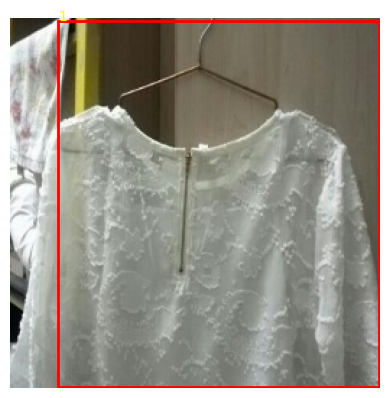

In [108]:
visualize(images[3], bboxes)

In [109]:
def get_gt_bboxes(annotation_path, category_map):
    bboxes = []

    with open(annotation_path, 'r') as f:
        data = json.load(f)

    for key in data:
        if not key.startswith("item"):
            continue

        obj = data[key]
        cid = obj["category_id"]

        if cid not in category_map:
            continue

        mapped = category_map[cid]

        x1, y1, x2, y2 = obj["bounding_box"]

        bboxes.append((x1, y1, x2, y2, mapped))

    return bboxes

In [118]:
def scale_bbox(box, original_size, new_size=256):
    x1, y1, x2, y2 = box
    H, W = original_size

    scale_x = new_size / W
    scale_y = new_size / H

    x1 = int(x1 * scale_x)
    x2 = int(x2 * scale_x)
    y1 = int(y1 * scale_y)
    y2 = int(y2 * scale_y)

    return x1, y1, x2, y2

In [110]:
def bbox_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    union = box1_area + box2_area - inter_area + 1e-6

    return inter_area / union

In [127]:
def evaluate_image_full(pred_boxes, gt_boxes, iou_threshold=0.5):
    matched = 0
    total_gt = len(gt_boxes)
    total_pred = len(pred_boxes)

    ious = []

    for px1, py1, px2, py2, pcls in pred_boxes:
        best_iou = 0

        for gx1, gy1, gx2, gy2, gcls in gt_boxes:
            if pcls != gcls:
                continue

            iou = bbox_iou((px1, py1, px2, py2),
                           (gx1, gy1, gx2, gy2))

            best_iou = max(best_iou, iou)

        if best_iou > 0:
            ious.append(best_iou)

        if best_iou >= iou_threshold:
            matched += 1

    return matched, total_pred, total_gt, ious

In [126]:
img_name = val_dataset.files[7]

ann_path = os.path.join(VAL_ANN_DIR, img_name.replace(".jpg", ".json"))

gt_boxes = get_gt_bboxes(ann_path, category_map)
pred_boxes = get_bboxes(preds[0])

# 🔥 ADD THIS PART
img = cv2.imread(os.path.join(VAL_IMAGE_DIR, img_name))
H, W, _ = img.shape

gt_boxes_scaled = []
for (x1, y1, x2, y2, cls) in gt_boxes:
    x1, y1, x2, y2 = scale_bbox((x1, y1, x2, y2), (H, W))
    gt_boxes_scaled.append((x1, y1, x2, y2, cls))

# ✅ Use scaled boxes
matched, total = evaluate_image(pred_boxes, gt_boxes_scaled)

print("Matched:", matched, "/", total)

Matched: 1 / 1


In [128]:
total_matched = 0
total_pred = 0
total_gt = 0

all_ious = []

for i in range(len(val_dataset)):
    img_name = val_dataset.files[i]

    # ---- Load image ----
    img_path = os.path.join(VAL_IMAGE_DIR, img_name)
    ann_path = os.path.join(VAL_ANN_DIR, img_name.replace(".jpg", ".json"))

    img = cv2.imread(img_path)
    H, W, _ = img.shape

    # ---- GT boxes ----
    gt_boxes = get_gt_bboxes(ann_path, category_map)

    gt_scaled = []
    for (x1, y1, x2, y2, cls) in gt_boxes:
        x1, y1, x2, y2 = scale_bbox((x1, y1, x2, y2), (H, W))
        gt_scaled.append((x1, y1, x2, y2, cls))

    # ---- Prediction ----
    image, _ = val_dataset[i]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)

    pred = torch.argmax(output, dim=1)
    pred_boxes = get_bboxes(pred[0])

    # ---- Evaluate ----
    matched, pred_n, gt_n, ious = evaluate_image_full(pred_boxes, gt_scaled)

    total_matched += matched
    total_pred += pred_n
    total_gt += gt_n
    all_ious.extend(ious)

In [129]:
precision = total_matched / (total_pred + 1e-6)
recall = total_matched / (total_gt + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

avg_iou = sum(all_ious) / len(all_ious) if len(all_ious) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Average IoU:", avg_iou)

Precision: 0.7166705525596486
Recall: 0.7922777534141228
F1 Score: 0.7525794711222539
Average IoU: 0.7352113034602372
